# Cardinality and threshold

This example walks from the simplest mixed-integer constraints to the most structured ones:

1. Asset-level cardinality and buy-in thresholds: `card`, `lt`, `st`.
2. Group cardinality over assets: `gcarde`.
3. Set-level cardinality and thresholds: `scard`, `slt`, `sst` with `smtx`.
4. Group-of-sets cardinality and thresholds: `sgcarde`, `sglt`, `sgst` with `sgmtx`.

The core idea is simple: constraints become more structured as you move from assets to sets to groups of sets.

> **When to reach for this**
>
> Reach for cardinality and threshold constraints when the *number* of positions matters as
> much as their sizes — enforcing a maximum count of holdings, a minimum buy-in so you never
> take dust positions, or limits on how many names, sets, or groups can be active. These are
> the tools for turning a dense optimiser solution into an implementable, sparse portfolio.

> **MIP required**
>
> These constraints introduce binary variables, so they need a mixed-integer-capable solver.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, HiGHS,
      Pajarito, JuMP, StatsPlots, GraphRecipes

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end

#2 (generic function with 1 method)

## 1. Setup

We use the same S&P 500 slice as the rest of the examples, but with the exact asset-set
fixtures that make the cardinality examples easy to read and, more importantly, feasible.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(HighOrderPriorEstimator(), rd)
rf = 4.2 / 100 / 252

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9)),
       Solver(; name = :clarabel4, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false, "max_step_fraction" => 0.85))]

mip_slv = [Solver(; name = :mip1,
                  solver = optimizer_with_attributes(Pajarito.Optimizer, "verbose" => false,
                                                     "oa_solver" =>
                                                         optimizer_with_attributes(HiGHS.Optimizer,
                                                                                   JuMP.MOI.Silent() =>
                                                                                       true),
                                                     "conic_solver" =>
                                                         optimizer_with_attributes(Clarabel.Optimizer,
                                                                                   "verbose" =>
                                                                                       false)),
                  check_sol = (; allow_local = true, allow_almost = true)),
           Solver(; name = :mip2,
                  solver = optimizer_with_attributes(Pajarito.Optimizer, "verbose" => false,
                                                     "oa_solver" =>
                                                         optimizer_with_attributes(HiGHS.Optimizer,
                                                                                   JuMP.MOI.Silent() =>
                                                                                       true),
                                                     "conic_solver" =>
                                                         optimizer_with_attributes(Clarabel.Optimizer,
                                                                                   "verbose" =>
                                                                                       false,
                                                                                   "max_step_fraction" =>
                                                                                       0.95)),
                  check_sol = (; allow_local = true, allow_almost = true))]

sets = AssetSets(;
                 dict = Dict("nx" => rd.nx, "group1" => rd.nx[1:2:end],
                             "group2" => rd.nx[2:2:end],
                             "clusters1" =>
                                 [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,
                                  3],
                             "clusters2" =>
                                 [1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1,
                                  2], "c1" => rd.nx[1:3:end], "c2" => rd.nx[2:3:end],
                             "c3" => rd.nx[3:3:end],
                             "nx_industries" => ["Technology", "Technology", "Financials",
                                                 "Consumer_Discretionary", "Energy", "Industrials",
                                                 "Consumer_Discretionary", "Healthcare", "Financials",
                                                 "Consumer_Staples", "Healthcare", "Healthcare",
                                                 "Technology", "Consumer_Staples", "Healthcare",
                                                 "Consumer_Staples", "Energy", "Healthcare",
                                                 "Consumer_Staples", "Energy"],
                             "ux_industries" =>
                                 ["Technology", "Financials", "Consumer_Discretionary",
                                  "Energy", "Industrials", "Healthcare",
                                  "Consumer_Staples"]))

AssetSets
   key ┼ String: "nx"
  ukey ┼ String: "ux"
  dict ┴ Dict{String, Vector}: Dict{String, Vector}("c2" => ["AMD", "CVX", "JNJ", "LLY", "PEP", "RRC", "XOM"], "nx" => ["AAPL", "AMD", "BAC", "BBY", "CVX", "GE", "HD", "JNJ", "JPM", "KO", "LLY", "MRK", "MSFT", "PEP", "PFE", "PG", "RRC", "UNH", "WMT", "XOM"], "c1" => ["AAPL", "BBY", "HD", "KO", "MSFT", "PG", "WMT"], "group2" => ["AMD", "BBY", "GE", "JNJ", "KO", "MRK", "PEP", "PG", "UNH", "XOM"], "clusters2" => [1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2], "nx_industries" => ["Technology", "Technology", "Financials", "Consumer_Discretionary", "Energy", "Industrials", "Consumer_Discretionary", "Healthcare", "Financials", "Consumer_Staples", "Healthcare", "Healthcare", "Technology", "Consumer_Staples", "Healthcare", "Consumer_Staples", "Energy", "Healthcare", "Consumer_Staples", "Energy"], "c3" => ["BAC", "GE", "JPM", "MRK", "PFE", "UNH"], "clusters1" => [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3], "ux_i

## 2. Asset-level: `card`, `lt`, `st`

`card` limits the number of significant assets.
`lt`/`st` are buy-in thresholds on individual long/short positions.

In [3]:
res_card = optimise(MeanRisk(; opt = JuMPOptimiser(; pe = pr, slv = mip_slv, card = 3)))

res_card_l2 = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                                opt = JuMPOptimiser(; l2 = 0.1, pe = pr, slv = mip_slv,
                                                    card = 3)))

res_card_thr = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                                 opt = JuMPOptimiser(; pe = pr, slv = mip_slv,
                                                     wb = WeightBounds(; lb = -1, ub = 1),
                                                     sbgt = 1, bgt = 1, card = 7)))

println("Asset-level cardinality")
println("  active assets (card = 3): ", count(res_card.w .> 1e-10))
println("  active assets (l2 + card = 3): ", count(res_card_l2.w .> 1e-10))
println("  active assets with bounds (card = 7): ", count(abs.(res_card_thr.w) .> 1e-10))
pretty_table(DataFrame(:Asset => rd.nx, :w_card => res_card.w, :w_card_l2 => res_card_l2.w,
                       :w_card_bounded => res_card_thr.w); formatters = [resfmt])

┌ Warning: integral solution repeated
└ @ Pajarito ~/.julia/packages/Pajarito/gSNvz/src/algorithms.jl:103
Asset-level cardinality
  active assets (card = 3): 3
  active assets (l2 + card = 3): 3
  active assets with bounds (card = 7): 7
┌────────┬──────────┬───────────┬────────────────┐
│  Asset │   w_card │ w_card_l2 │ w_card_bounded │
│ String │  Float64 │   Float64 │        Float64 │
├────────┼──────────┼───────────┼────────────────┤
│   AAPL │    0.0 % │     0.0 % │         -0.0 % │
│    AMD │    0.0 % │     0.0 % │      -27.666 % │
│    BAC │    0.0 % │     0.0 % │         -0.0 % │
│    BBY │    0.0 % │     0.0 % │        4.284 % │
│    CVX │    0.0 % │  30.163 % │         -0.0 % │
│     GE │    0.0 % │     0.0 % │         -0.0 % │
│     HD │    0.0 % │     0.0 % │         -0.0 % │
│    JNJ │    0.0 % │     0.0 % │         -0.0 % │
│    JPM │    0.0 % │     0.0 % │         -0.0 % │
│     KO │    0.0 % │     0.0 % │       11.873 % │
│    LLY │    0.0 % │     0.0 % │       29.323 % 

## 3. Group cardinality over assets: `gcarde`

`gcarde` uses linear group expressions to constrain how many assets in a named group can be active.

In [4]:
res_gcard = optimise(MeanRisk(;
                              opt = JuMPOptimiser(; pe = pr, slv = mip_slv,
                                                  gcarde = LinearConstraintEstimator(;
                                                                                     val = [:(XOM +
                                                                                              MRK +
                                                                                              WMT <=
                                                                                              2),
                                                                                            :(group2 ==
                                                                                              5)]),
                                                  sets = sets)))

println("Group cardinality over assets")
println("  active names in XOM/MRK/WMT group: ",
        count(res_gcard.w[.!iszero.(vec(res_gcard.gcardr.A_ineq[1, :]))] .> 1e-10))
println("  active names in group2: ",
        count(res_gcard.w[.!iszero.(vec(res_gcard.gcardr.A_eq[1, :]))] .> 1e-10))

Group cardinality over assets
  active names in XOM/MRK/WMT group: 2
  active names in group2: 5


## 4. Set-level: `scard`, `slt`, `sst` with `smtx`

Here the constraints act on the **sum of the weights in each set**.
- `smtx` maps assets to sets.
- `scard` limits the number of active sets.
- `slt`/`sst` threshold the set-level sums.

In [5]:
res_set_1 = optimise(MeanRisk(; r = ConditionalValueatRisk(), obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = pr, slv = mip_slv, scard = 1,
                                                  smtx = AssetSetsMatrixEstimator(;
                                                                                  val = "clusters1"),
                                                  sets = sets)), rd)

res_set_2 = optimise(MeanRisk(; r = ConditionalValueatRisk(), obj = MaximumRatio(; rf = rf),
                              opt = JuMPOptimiser(; pe = pr, slv = mip_slv, scard = 2,
                                                  slt = Threshold(; val = fill(0.73, 3)),
                                                  sst = Threshold(; val = 0.38),
                                                  wb = WeightBounds(; lb = -1, ub = 1),
                                                  sbgt = 1, bgt = nothing,
                                                  smtx = AssetSetsMatrixEstimator(;
                                                                                  val = "clusters1"),
                                                  sets = sets)), rd)

set_exposure = res_set_2.smtx * res_set_2.w
println("Set-level cardinality and thresholds")
println("  active sets (scard = 1): ",
        count(.!iszero.([sum(res_set_1.w[res_set_1.smtx[i, :]]) for i in axes(res_set_1.smtx, 1)])))
println("  active sets (scard = 2): ",
        count(.!iszero.([sum(res_set_2.w[res_set_2.smtx[i, :]]) for i in axes(res_set_2.smtx, 1)])))
println("  min set exposure: ", minimum(set_exposure))
println("  max set exposure: ", maximum(set_exposure))
pretty_table(DataFrame(:Set => ["cluster 1", "cluster 2", "cluster 3"],
                       :set_exposure => set_exposure); formatters = [resfmt])

Set-level cardinality and thresholds
  active sets (scard = 1): 1
  active sets (scard = 2): 3
  min set exposure: -0.3800000000000003
  max set exposure: 0.7300000000000001
┌───────────┬──────────────┐
│       Set │ set_exposure │
│    String │      Float64 │
├───────────┼──────────────┤
│ cluster 1 │      -38.0 % │
│ cluster 2 │       73.0 % │
│ cluster 3 │       -0.0 % │
└───────────┴──────────────┘


## 5. Group-of-sets: `sgcarde`, `sglt`, `sgst` with `sgmtx`

Now the constraints are defined over groups of sets, not directly over assets.
- `sgmtx` maps assets to set groups.
- `sgcarde` constrains cardinality over those groups.
- `sglt`/`sgst` threshold grouped set exposures.

Feasibility still depends on the budget and the bounds, so we use the same values as the tested
constraint block.

In [6]:
res_sg_1 = optimise(MeanRisk(;
                             opt = JuMPOptimiser(; slv = mip_slv, sets = sets,
                                                 sglt = Threshold(0.015),
                                                 sgcarde = LinearConstraintEstimator(;
                                                                                     key = "ux_industries",
                                                                                     val = [:(ux_industries ==
                                                                                              4)]),
                                                 sgmtx = AssetSetsMatrixEstimator(;
                                                                                  val = "nx_industries"))),
                    rd)

res_sg_2 = optimise(MeanRisk(;
                             opt = JuMPOptimiser(; slv = mip_slv,
                                                 wb = WeightBounds(; lb = -1, ub = 1),
                                                 sbgt = 1, bgt = nothing,
                                                 sglt = [ThresholdEstimator(;
                                                                            val = fill(0.53,
                                                                                       7),
                                                                            key = "ux_industries")],
                                                 sgst = [ThresholdEstimator(;
                                                                            val = fill(0.32,
                                                                                       7),
                                                                            key = "ux_industries")],
                                                 sgcarde = [LinearConstraintEstimator(;
                                                                                      key = "ux_industries",
                                                                                      val = [:(ux_industries >=
                                                                                               4),
                                                                                             :(ux_industries <=
                                                                                               6)])],
                                                 sgmtx = [AssetSetsMatrixEstimator(;
                                                                                   val = "nx_industries")],
                                                 sets = sets)), rd)

group_exposure_1 = res_sg_1.sgmtx * res_sg_1.w
group_exposure_2 = res_sg_2.sgmtx[1] * res_sg_2.w
println("Group-of-sets constraints")
println("  grouped set count (single constraint run): ",
        count(abs.(group_exposure_1) .> 1e-10))
println("  grouped set count (threshold run): ", count(abs.(group_exposure_2) .> 5e-10))
println("  min grouped long exposure: ", minimum(group_exposure_2[group_exposure_2 .> 0]))
println("  max grouped short exposure: ", maximum(group_exposure_2[group_exposure_2 .< 0]))
pretty_table(DataFrame(:GroupSet => sets.dict["ux_industries"],
                       :group_exposure => group_exposure_2); formatters = [resfmt])

Group-of-sets constraints
  grouped set count (single constraint run): 4
  grouped set count (threshold run): 4
  min grouped long exposure: 3.937870359587109e-15
  max grouped short exposure: -0.32000010544262647
┌────────────────────────┬────────────────┐
│               GroupSet │ group_exposure │
│                 String │        Float64 │
├────────────────────────┼────────────────┤
│             Technology │          0.0 % │
│             Financials │        -32.0 % │
│ Consumer_Discretionary │         53.0 % │
│                 Energy │          0.0 % │
│            Industrials │          0.0 % │
│             Healthcare │        -32.0 % │
│       Consumer_Staples │        -32.0 % │
└────────────────────────┴────────────────┘


## 6. Side-by-side summary

In [7]:
pretty_table(DataFrame("Case" => ["asset card", "asset card + l2", "gcarde", "set-level",
                                  "group-of-sets"],
                       "Active assets" =>
                           [count(res_card.w .> 1e-10), count(res_card_l2.w .> 1e-10),
                            count(res_gcard.w .> 1e-10), count(res_set_1.w .> 1e-10),
                            count(res_sg_1.w .> 1e-10)]))

┌─────────────────┬───────────────┐
│            Case │ Active assets │
│          String │         Int64 │
├─────────────────┼───────────────┤
│      asset card │             3 │
│ asset card + l2 │             3 │
│          gcarde │            15 │
│       set-level │             4 │
│   group-of-sets │            14 │
└─────────────────┴───────────────┘


## 7. Composition across constraint families

A final visual comparison of how each constraint family reshapes the allocation: asset-level
cardinality collapses to a few names, while the set- and group-level constraints spread the
budget across the structure they are defined on.

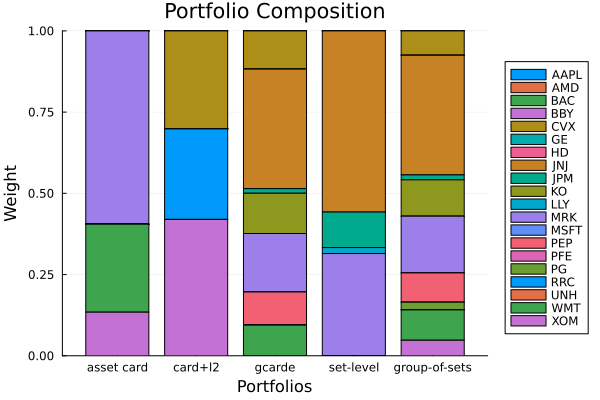

In [8]:
plot_stacked_bar_composition([res_card, res_card_l2, res_gcard, res_set_1, res_sg_1], rd;
                             xticks = ([1, 2, 3, 4, 5],
                                       ["asset card", "card+l2", "gcarde", "set-level",
                                        "group-of-sets"]))

Takeaways:

- Use `card`, `lt`, `st` for direct asset-level sparsity and buy-in behavior.
- Use `gcarde` when the constraint is a linear statement over a named asset group.
- Use `smtx` + `scard`/`slt`/`sst` when the constraint should apply to set sums.
- Use `sgmtx` + `sgcarde`/`sglt`/`sgst` when the constraint should apply to groups of sets.
- If the solver returns an infeasible or failed retcode, the threshold or cardinality target is too tight for the available budget and bounds.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*